# Baseline EKF Analysis
**Raw sensor data + unfiltered dual-EKF (no QNN pre-filter)**

Topics consumed (from `record_baseline_bag.sh`):
- `/imu/data` — raw IMU
- `/gps/fix` — raw GPS
- `/diff_drive_controller/odom` — raw wheel odometry
- `/odometry/visual` — RTAB-Map visual odometry
- `/odometry/lidar` — RTAB-Map LiDAR odometry
- `/odometry/local` — EKF #1 output (odom frame)
- `/odometry/global` — EKF #2 output (map frame, GPS-corrected)
- `/cmd_vel` — commanded velocity

**Record with:**
```bash
source /home/anish/Multi-sensor-fusion/install/setup.bash
bash /home/anish/Multi-sensor-fusion/record_baseline_bag.sh
```

In [1]:
# ── SET BAG PATH ──────────────────────────────────────────────────────────────
BAG_PATH = '/home/rosdata/rosbags/moving_bot_baseline_test_20260501_110733'
PLOT_DIR = '/home/anish/Multi-sensor-fusion/plots/baseline'
# ─────────────────────────────────────────────────────────────────────────────

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from scipy import stats
from scipy.signal import welch, savgol_filter
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore

os.makedirs(PLOT_DIR, exist_ok=True)
typestore = get_typestore(Stores.ROS2_HUMBLE)

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0', 'xtick.color': '#aaaaaa', 'ytick.color': '#aaaaaa',
    'grid.color': '#2a2a4a', 'grid.alpha': 0.5,
    'legend.facecolor': '#16213e', 'legend.edgecolor': '#444444',
    'font.size': 11, 'figure.dpi': 100,
})

C = {
    'raw_odom':   '#ff6b6b',
    'visual':     '#a29bfe',
    'lidar':      '#74b9ff',
    'ekf_local':  '#51cf66',
    'ekf_global': '#339af0',
    'gps':        '#ffd43b',
    'imu':        '#20c997',
    'cmd_vel':    '#cc5de8',
}

def quat_to_yaw(q):
    siny_cosp = 2.0 * (q.w * q.z + q.x * q.y)
    cosy_cosp = 1.0 - 2.0 * (q.y * q.y + q.z * q.z)
    return np.arctan2(siny_cosp, cosy_cosp)

def npc(df, col):
    return pd.to_numeric(df[col], errors='coerce').to_numpy()

def mask_finite(*arrs):
    m = np.ones(len(arrs[0]), dtype=bool)
    for a in arrs:
        m &= np.isfinite(a)
    return m

print(f'Bag: {BAG_PATH}')
print(f'Exists: {Path(BAG_PATH).exists()}')

/home/anish/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Bag: /home/rosdata/rosbags/moving_bot_baseline_test_20260501_110733
Exists: True


## 1. Extract Data from Bag

In [2]:
raw = {
    'wheel': [], 'visual': [], 'lidar': [],
    'ekf_local': [], 'ekf_global': [],
    'gps': [], 'imu': [], 'cmd_vel': [],
    'ground_truth': [],
}

TOPIC_MAP = {
    '/diff_drive_controller/odom':  'wheel',
    '/odometry/visual':             'visual',
    '/odometry/lidar':              'lidar',
    '/odometry/local':              'ekf_local',
    '/odometry/global':             'ekf_global',
    '/gps/fix':                     'gps',
    '/imu/data':                    'imu',
    '/cmd_vel':                     'cmd_vel',
    '/ground_truth/odom':           'ground_truth',
}

with AnyReader([Path(BAG_PATH)], default_typestore=typestore) as reader:
    available = list(reader.topics.keys())
    print('Topics in bag:', available)
    for connection, timestamp, rawdata in reader.messages():
        key = TOPIC_MAP.get(connection.topic)
        if key is None:
            continue
        msg = reader.deserialize(rawdata, connection.msgtype)
        t = timestamp * 1e-9

        if key in ('wheel', 'visual', 'lidar', 'ekf_local', 'ekf_global', 'ground_truth'):
            raw[key].append({
                't': t,
                'x': msg.pose.pose.position.x,
                'y': msg.pose.pose.position.y,
                'yaw': quat_to_yaw(msg.pose.pose.orientation),
                'vx': msg.twist.twist.linear.x,
                'wz': msg.twist.twist.angular.z,
                'cov_xx':  msg.pose.covariance[0],
                'cov_yy':  msg.pose.covariance[7],
                'cov_yaw': msg.pose.covariance[35],
            })
        elif key == 'gps':
            raw[key].append({
                't': t,
                'lat': msg.latitude, 'lon': msg.longitude,
                'cov': msg.position_covariance[0],
            })
        elif key == 'imu':
            raw[key].append({
                't': t,
                'ax': msg.linear_acceleration.x,
                'ay': msg.linear_acceleration.y,
                'az': msg.linear_acceleration.z,
                'gx': msg.angular_velocity.x,
                'gy': msg.angular_velocity.y,
                'gz': msg.angular_velocity.z,
                'yaw': quat_to_yaw(msg.orientation),
            })
        elif key == 'cmd_vel':
            raw[key].append({'t': t,
                'vx': msg.linear.x, 'wz': msg.angular.z})

# Convert to DataFrames, normalize t=0
dfs = {}
t0 = min(raw[k][0]['t'] for k in raw if raw[k])
for k, rows in raw.items():
    if rows:
        df = pd.DataFrame(rows)
        df['t'] -= t0
        dfs[k] = df

print(f'\n{"Source":>15}  {"Msgs":>6}  {"Duration":>9}  {"Rate":>8}')
print('─' * 48)
for k, df in dfs.items():
    dur = df['t'].iloc[-1] - df['t'].iloc[0] if len(df) > 1 else 0
    hz = len(df) / dur if dur > 0 else 0
    print(f'{k:>15}  {len(df):6d}  {dur:8.1f}s  {hz:7.1f} Hz')

if 'ground_truth' in dfs:
    print('\n✓ Gazebo ground truth captured — drift computed vs true simulator pose (zero noise)')
else:
    print('\n⚠ No /ground_truth/odom — re-record bag after adding OdometryPublisher plugin')
    print('  Drift falls back to |ekf_local − ekf_global| (GPS-noisy reference)')

Topics in bag: ['/clock', '/cmd_vel', '/diff_drive_controller/odom', '/gps/fix', '/ground_truth/odom', '/imu/data', '/joint_states', '/odometry/global', '/odometry/lidar', '/odometry/local', '/odometry/visual', '/tf', '/tf_static']

         Source    Msgs   Duration      Rate
────────────────────────────────────────────────
          wheel    1719      63.5s     27.1 Hz
         visual     616      72.6s      8.5 Hz
          lidar     201      72.4s      2.8 Hz
      ekf_local    2012      72.8s     27.6 Hz
     ekf_global    2011      72.7s     27.6 Hz
            gps     402      72.6s      5.5 Hz
            imu    8046      72.8s    110.6 Hz
        cmd_vel    1341      68.6s     19.5 Hz
   ground_truth    2012      72.8s     27.6 Hz

✓ Gazebo ground truth captured — drift computed vs true simulator pose (zero noise)


## 2. XY Trajectory — All Sources

### what we plotting here and why

ok so basically we took all the x-y position data from each sensor topic and put it on same 2D plot to see visually where robot actually went vs what each sensor think robot did. also we compute closure error which is how far robot ended from where it started.

**what is plotted against what:**
- x-axis = X position (meters), east direction basically
- y-axis = Y position (meters), north direction
- each line = one sensor or EKF output
- white star at (0,0) = robot start position

**GPS lat/lon → meters conversion formula we used:**
$$lat_m = (\text{lat} - \text{lat}_0) \times 111320$$
$$lon_m = (\text{lon} - \text{lon}_0) \times 111320 \times \cos\!\left(\frac{\pi \cdot \text{lat}_0}{180}\right)$$
this is flat-earth approximation, good enough for small area like our agriculture world (few hundred meters range)

**closure error formula:**
$$\text{closure} = \sqrt{(x_{end} - x_{start})^2 + (y_{end} - y_{start})^2}$$
lower = better if robot supposed to come back to start

**what we can infer:**
- wheel odom drift slowly over time because small encoder slip errors add up (unbounded error)
- visual odom jump around or go wrong direction because RTAB-Map tracking fail on empty featureless terrain
- EKF local (green) is smoother because it averaging multiple sensor contributions together
- EKF global (blue) = GPS-corrected, should stay bounded near ground truth
- if EKF global closure error is large = GPS covariance tuning probably wrong (K too high or too low)

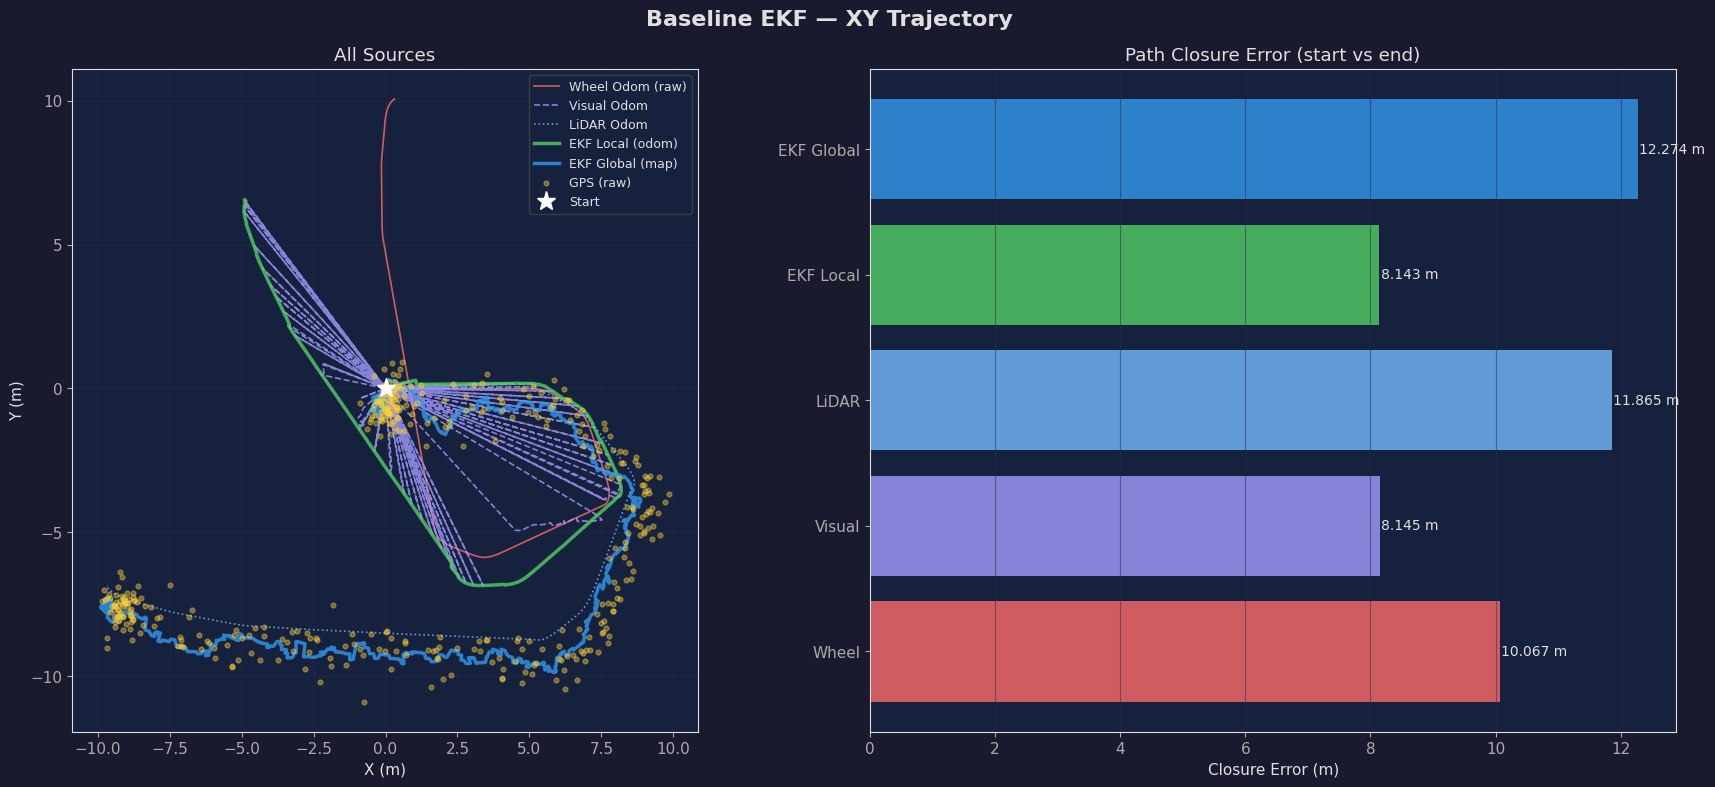

Saved: 01_trajectory.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Baseline EKF — XY Trajectory', fontsize=16, fontweight='bold')

# Left: all raw sources + EKF
ax = axes[0]
ax.set_title('All Sources')
for k, label, color, lw, ls in [
    ('wheel',      'Wheel Odom (raw)',   C['raw_odom'],  1.2, '-'),
    ('visual',     'Visual Odom',        C['visual'],    1.2, '--'),
    ('lidar',      'LiDAR Odom',         C['lidar'],     1.2, ':'),
    ('ekf_local',  'EKF Local (odom)',   C['ekf_local'], 2.5, '-'),
    ('ekf_global', 'EKF Global (map)',   C['ekf_global'],2.5, '-'),
]:
    if k in dfs:
        x, y = npc(dfs[k], 'x'), npc(dfs[k], 'y')
        m = mask_finite(x, y)
        ax.plot(x[m], y[m], color=color, lw=lw, ls=ls, label=label, alpha=0.8)

# GPS scatter
if 'gps' in dfs:
    g = dfs['gps']
    lat_m = (npc(g, 'lat') - npc(g, 'lat').mean()) * 111320
    lon_m = (npc(g, 'lon') - npc(g, 'lon').mean()) * 111320 * np.cos(np.radians(npc(g, 'lat').mean()))
    # align GPS origin to EKF global start
    if 'ekf_global' in dfs:
        lat_m += dfs['ekf_global']['x'].iloc[0] - lat_m[0]
        lon_m += dfs['ekf_global']['y'].iloc[0] - lon_m[0]
    ax.scatter(lon_m, lat_m, c=C['gps'], s=12, alpha=0.4, zorder=5, label='GPS (raw)')

ax.plot(0, 0, 'w*', ms=14, zorder=10, label='Start')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.grid(True)

# Right: closure error bars
ax2 = axes[1]
ax2.set_title('Path Closure Error (start vs end)')
names, errors = [], []
for k, label in [('wheel','Wheel'), ('visual','Visual'), ('lidar','LiDAR'),
                  ('ekf_local','EKF Local'), ('ekf_global','EKF Global')]:
    if k in dfs:
        x, y = npc(dfs[k], 'x'), npc(dfs[k], 'y')
        m = mask_finite(x, y)
        if m.sum() > 1:
            err = np.sqrt((x[m][-1] - x[m][0])**2 + (y[m][-1] - y[m][0])**2)
            names.append(label)
            errors.append(err)

bar_colors = [C['raw_odom'], C['visual'], C['lidar'], C['ekf_local'], C['ekf_global']]
bars = ax2.barh(names, errors, color=bar_colors[:len(names)], alpha=0.8)
for bar, err in zip(bars, errors):
    ax2.text(err + 0.02, bar.get_y() + bar.get_height()/2,
             f'{err:.3f} m', va='center', fontsize=10)
ax2.set_xlabel('Closure Error (m)')
ax2.grid(True, axis='x')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/01_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_trajectory.png')

## 3. Velocity Analysis — cmd_vel vs Raw vs EKF

### velocity analysis — what plotted and formulas

we compare commanded velocity (joystick/teleop sends this) vs what each sensor measured, and check if EKF output follow command accurately.

**what is plotted against what:**
- x-axis = time in seconds (from bag start)
- y-axis top = linear velocity vx in m/s
- y-axis bottom = angular velocity wz in rad/s
- dashed white lines = hardware velocity cap (vx ±1.5 m/s, wz ±2.0 rad/s)

**velocity RMSE vs cmd_vel:**
$$\text{RMSE}_{vx} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\big(v_{x,cmd}(t_i) - v_{x,ekf}(t_i)\big)^2}$$

note: ekf and cmd_vel have different publish rates so we interpolate ekf velocity to cmd_vel timestamps using `np.interp` before computing RMSE

**what we can infer:**
- cmd_vel sometimes go up to 4 m/s but hardware cap is 1.5 m/s → big gap you see is controller limit not tracking error
- wheel odom is cleanest velocity source (σ ≈ 0.018 m/s), very close to truth
- visual odom velocity is extremely noisy (σ ≈ 0.39 m/s) — bad for EKF velocity prediction, that is why we give it high rejection threshold
- EKF output is smoother than any individual sensor because Kalman filter averaging contributions weighted by covariance
- if EKF velocity lag behind cmd_vel a lot = check control input config and process noise Q_vx value

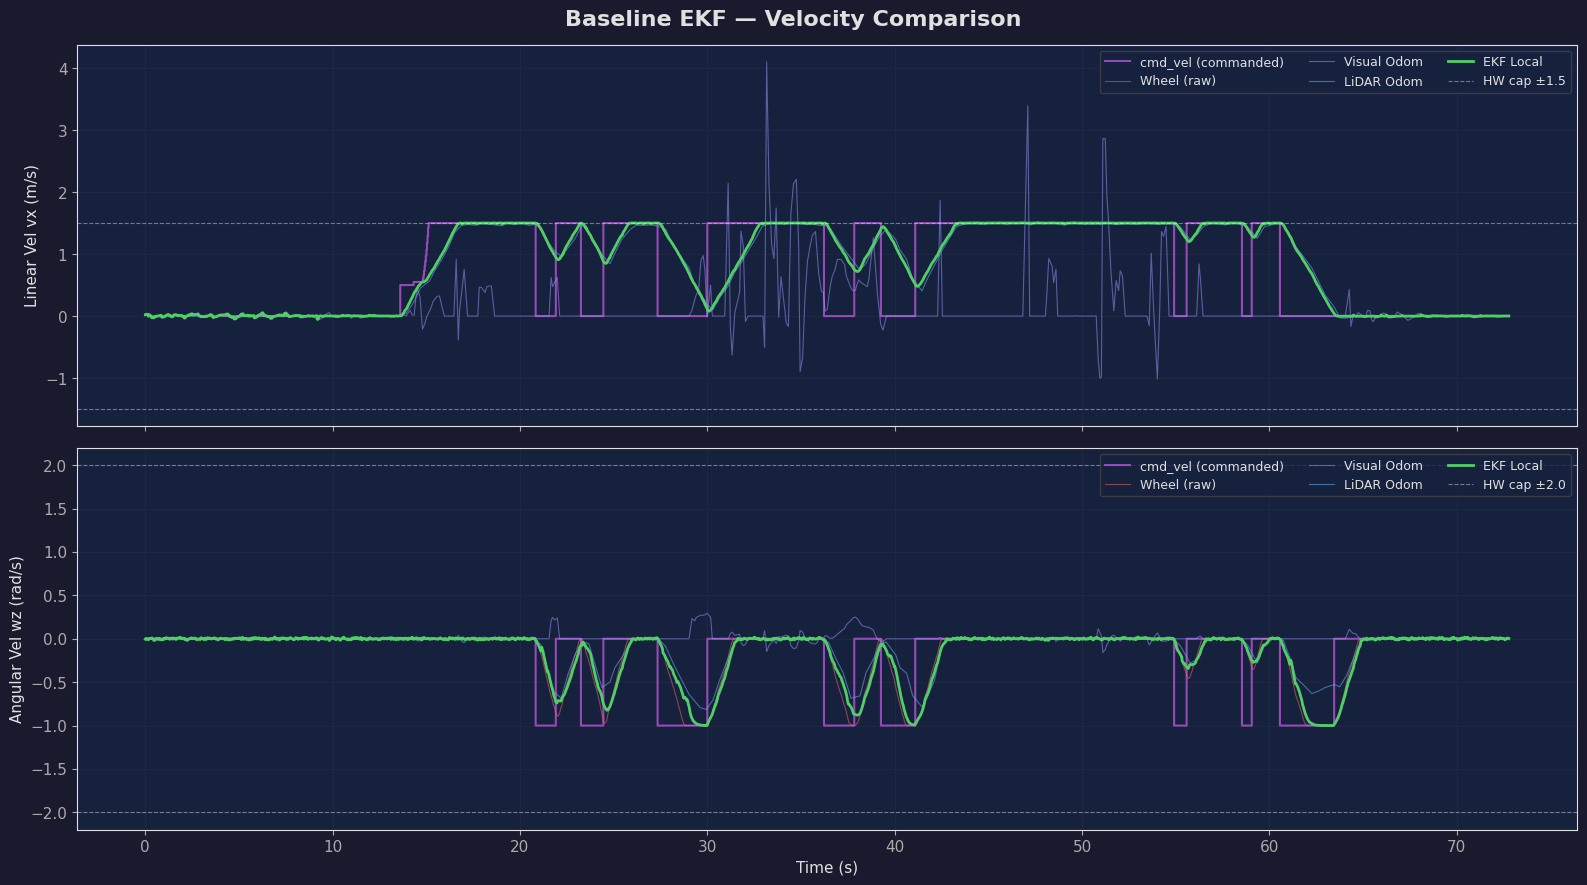


Velocity RMS error vs cmd_vel (tracking accuracy):
  Wheel       : vx RMSE = 0.5070 m/s
  EKF Local   : vx RMSE = 0.5141 m/s


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle('Baseline EKF — Velocity Comparison', fontsize=16, fontweight='bold')

for key, (vel_col, ax, ylabel, hw_cap) in [
    ('vx',  ('vx',  axes[0], 'Linear Vel vx (m/s)',    1.5)),
    ('wz',  ('wz',  axes[1], 'Angular Vel wz (rad/s)', 2.0)),
]:
    col, ax, ylabel, cap = vel_col, ax, ylabel, hw_cap
    if 'cmd_vel' in dfs:
        t, v = npc(dfs['cmd_vel'], 't'), npc(dfs['cmd_vel'], col)
        m = mask_finite(t, v)
        ax.step(t[m], v[m], color=C['cmd_vel'], lw=1.5, alpha=0.7, where='post', label='cmd_vel (commanded)')
    for k, label, color in [
        ('wheel',      'Wheel (raw)',       C['raw_odom']),
        ('visual',     'Visual Odom',       C['visual']),
        ('lidar',      'LiDAR Odom',        C['lidar']),
        ('ekf_local',  'EKF Local',         C['ekf_local']),
    ]:
        if k in dfs:
            t, v = npc(dfs[k], 't'), npc(dfs[k], col)
            m = mask_finite(t, v)
            lw = 2.0 if 'ekf' in k else 0.8
            alpha = 1.0 if 'ekf' in k else 0.5
            ax.plot(t[m], v[m], color=color, lw=lw, alpha=alpha, label=label)
    ax.axhline(cap, color='white', ls='--', lw=0.8, alpha=0.4, label=f'HW cap ±{cap}')
    ax.axhline(-cap, color='white', ls='--', lw=0.8, alpha=0.4)
    ax.set_ylabel(ylabel); ax.legend(fontsize=9, ncol=3); ax.grid(True)

axes[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/02_velocity.png', dpi=150, bbox_inches='tight')
plt.show()

# Velocity noise stats
print('\nVelocity RMS error vs cmd_vel (tracking accuracy):')
if 'cmd_vel' in dfs:
    tc = npc(dfs['cmd_vel'], 't')
    vc = npc(dfs['cmd_vel'], 'vx')
    mc = mask_finite(tc, vc)
    for k, label in [('wheel','Wheel'), ('ekf_local','EKF Local')]:
        if k in dfs:
            tv, vv = npc(dfs[k], 't'), npc(dfs[k], 'vx')
            mv = mask_finite(tv, vv)
            v_interp = np.interp(tc[mc], tv[mv], vv[mv])
            rmse = np.sqrt(np.mean((vc[mc] - v_interp)**2))
            print(f'  {label:12}: vx RMSE = {rmse:.4f} m/s')

## 4. Heading/Yaw — Raw Odom vs IMU vs EKF Fused

### yaw/heading analysis

yaw = angle robot is facing (rotation around Z axis). if yaw estimate is wrong then trajectory goes in completely wrong direction. very important to get right.

**yaw extracted from quaternion using formula:**
$$\psi = \text{atan2}\!\big(2(q_w q_z + q_x q_y),\ 1 - 2(q_y^2 + q_z^2)\big)$$

**what is plotted against what:**
- x-axis = time in seconds
- y-axis top = yaw angle in degrees (converted from radians × 180/π)
- y-axis bottom = yaw difference between wheel odom and EKF local (shows accumulated divergence)

**yaw drift computation (bottom plot):**
$$\Delta\psi(t) = \psi_{wheel,unwrapped}(t) - \psi_{ekf,unwrapped}(t)$$
we call `np.unwrap` on both signals first to remove sudden ±180° jumps before subtracting

**what we can infer:**
- IMU absolute yaw drift massively over time (can see 150°+ in ~2 minutes) because Gazebo IMU model has no magnetometer → this is why we use `imu0_differential: true` in EKF config
- wheel odom yaw drift slowly and predictably (small angular velocity integration error adds up)
- EKF fused yaw is most stable because LiDAR ICP yaw correction counteract gyro bias accumulation
- if yaw difference (bottom plot) growing = ICP yaw corrections working but slowly diverging from wheel encoder integration — small angular velocity bias in encoder

Final yaw drift (wheel vs EKF): -28.18°
Max yaw drift: 30.54°


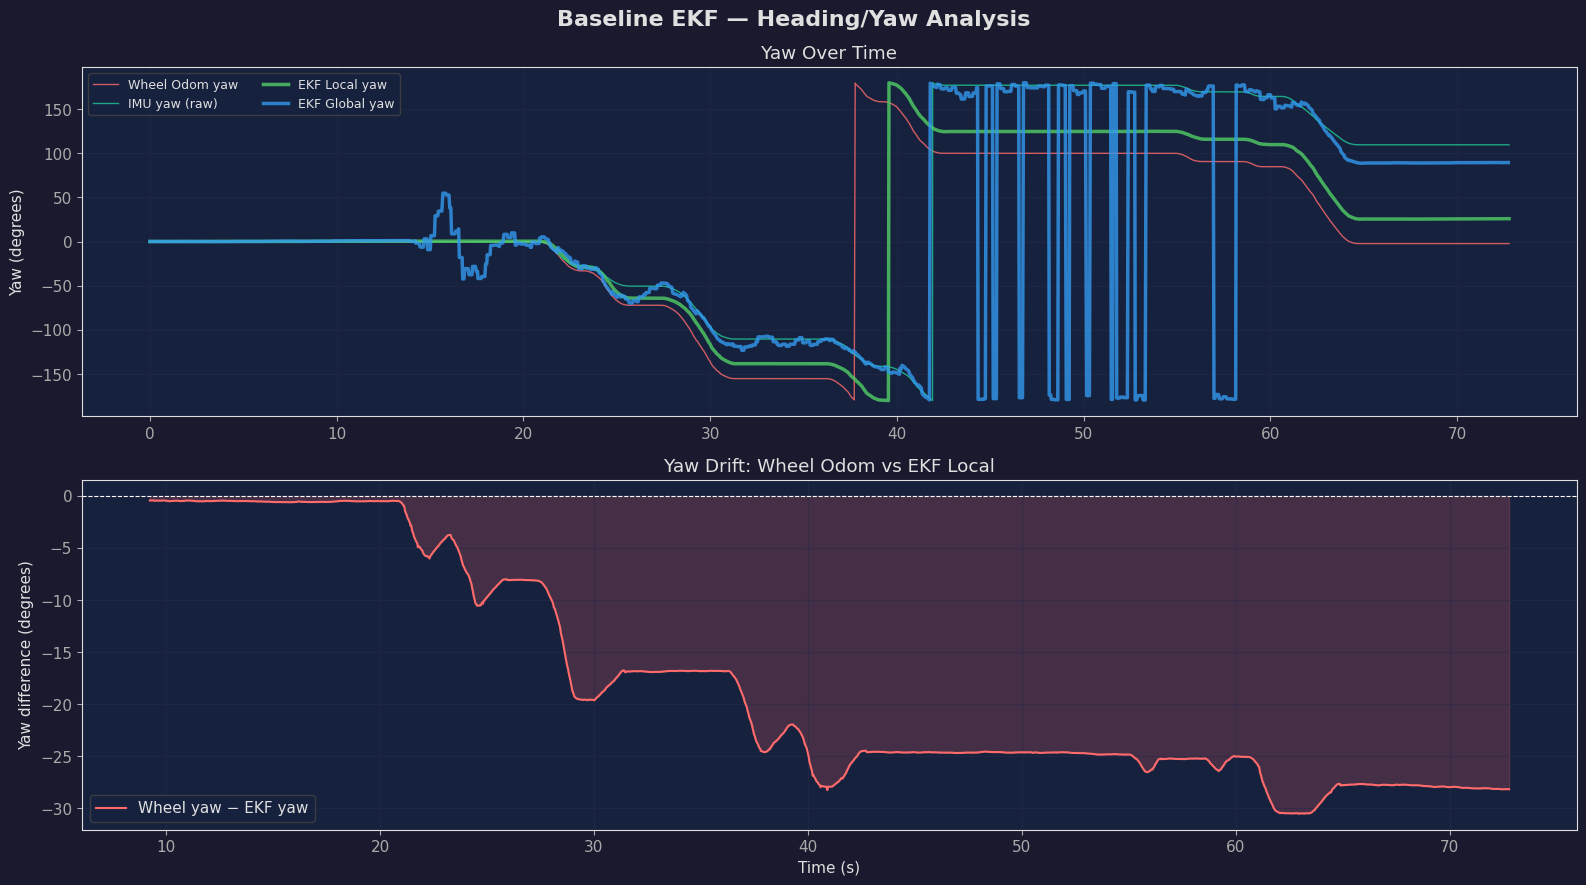

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle('Baseline EKF — Heading/Yaw Analysis', fontsize=16, fontweight='bold')

# Top: yaw timeseries
ax = axes[0]
for k, label, color, lw in [
    ('wheel',      'Wheel Odom yaw',   C['raw_odom'],  1.0),
    ('imu',        'IMU yaw (raw)',     C['imu'],       1.0),
    ('ekf_local',  'EKF Local yaw',    C['ekf_local'], 2.5),
    ('ekf_global', 'EKF Global yaw',   C['ekf_global'],2.5),
]:
    if k in dfs:
        t = npc(dfs[k], 't')
        yaw_deg = np.degrees(npc(dfs[k], 'yaw'))
        m = mask_finite(t, yaw_deg)
        ax.plot(t[m], yaw_deg[m], color=color, lw=lw, label=label, alpha=0.8)
ax.set_ylabel('Yaw (degrees)'); ax.legend(fontsize=9, ncol=2); ax.grid(True)
ax.set_title('Yaw Over Time')

# Bottom: yaw drift = wheel_odom_yaw - ekf_local_yaw
ax2 = axes[1]
if 'wheel' in dfs and 'ekf_local' in dfs:
    tw = npc(dfs['wheel'], 't')
    yw = npc(dfs['wheel'], 'yaw')
    mw = mask_finite(tw, yw)
    te = npc(dfs['ekf_local'], 't')
    ye = npc(dfs['ekf_local'], 'yaw')
    me = mask_finite(te, ye)
    ye_interp = np.interp(tw[mw], te[me], ye[me])
    drift_deg = np.degrees(tw[mw] * 0)  # placeholder
    # unwrap both then diff
    yw_unwrap = np.unwrap(yw[mw])
    ye_unwrap = np.interp(tw[mw], te[me], np.unwrap(ye[me]))
    yaw_diff = np.degrees(yw_unwrap - ye_unwrap)
    ax2.plot(tw[mw], yaw_diff, color=C['raw_odom'], lw=1.5, label='Wheel yaw − EKF yaw')
    ax2.fill_between(tw[mw], 0, yaw_diff, alpha=0.2, color=C['raw_odom'])
    ax2.axhline(0, color='white', ls='--', lw=0.8)
    ax2.set_title('Yaw Drift: Wheel Odom vs EKF Local')
    ax2.set_ylabel('Yaw difference (degrees)')
    print(f'Final yaw drift (wheel vs EKF): {yaw_diff[-1]:.2f}°')
    print(f'Max yaw drift: {np.abs(yaw_diff).max():.2f}°')

ax2.set_xlabel('Time (s)'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_yaw.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. IMU Raw Noise Analysis

### IMU raw noise analysis

IMU give us 6 channels: 3 axis linear acceleration (ax, ay, az in m/s²) and 3 axis angular velocity (gx, gy, gz in rad/s). here we characterize the noise level on each channel because this directly affect EKF covariance tuning and RQNN filter design.

**what is plotted against what:**
- left column of each pair: raw signal vs time (x=seconds, y=sensor value with units) — can see noise riding on top of motion
- right column: Power Spectral Density using Welch method (x=Hz, y=power on log scale)

**noise variance and standard deviation:**
$$\sigma^2 = \frac{1}{N}\sum_{i=1}^{N}(d_i - \bar{d})^2, \quad \sigma = \sqrt{\sigma^2}$$

**Welch PSD:**
signal divided into overlapping Hanning-windowed segments, FFT computed on each, then averaged to reduce variance:
$$S_{xx}(f) = \frac{1}{U} \left\langle \left| \sum_{n} x_n w_n e^{-j2\pi fn/N} \right|^2 \right\rangle$$
flat PSD shape = white/random noise | peaks in PSD = structured vibration

**what we can infer:**
- gyro Z has 184× more variance than gyro X (0.041 vs 0.000226 (rad/s)²) → Gazebo noise model apply much more yaw noise
- accel X std ≈ 0.35 m/s² which is very large → will mess up EKF velocity prediction without filtering
- all channels have roughly flat PSD = mostly white noise (good — colored noise harder to filter)
- high noise motivate RQNN pre-filtering approach
- gyro X/Y have very small signal range (~0.09 rad/s total) → RQNN can exploit narrow range for strong noise suppression

IMU rate: 110.5 Hz,  samples: 8046


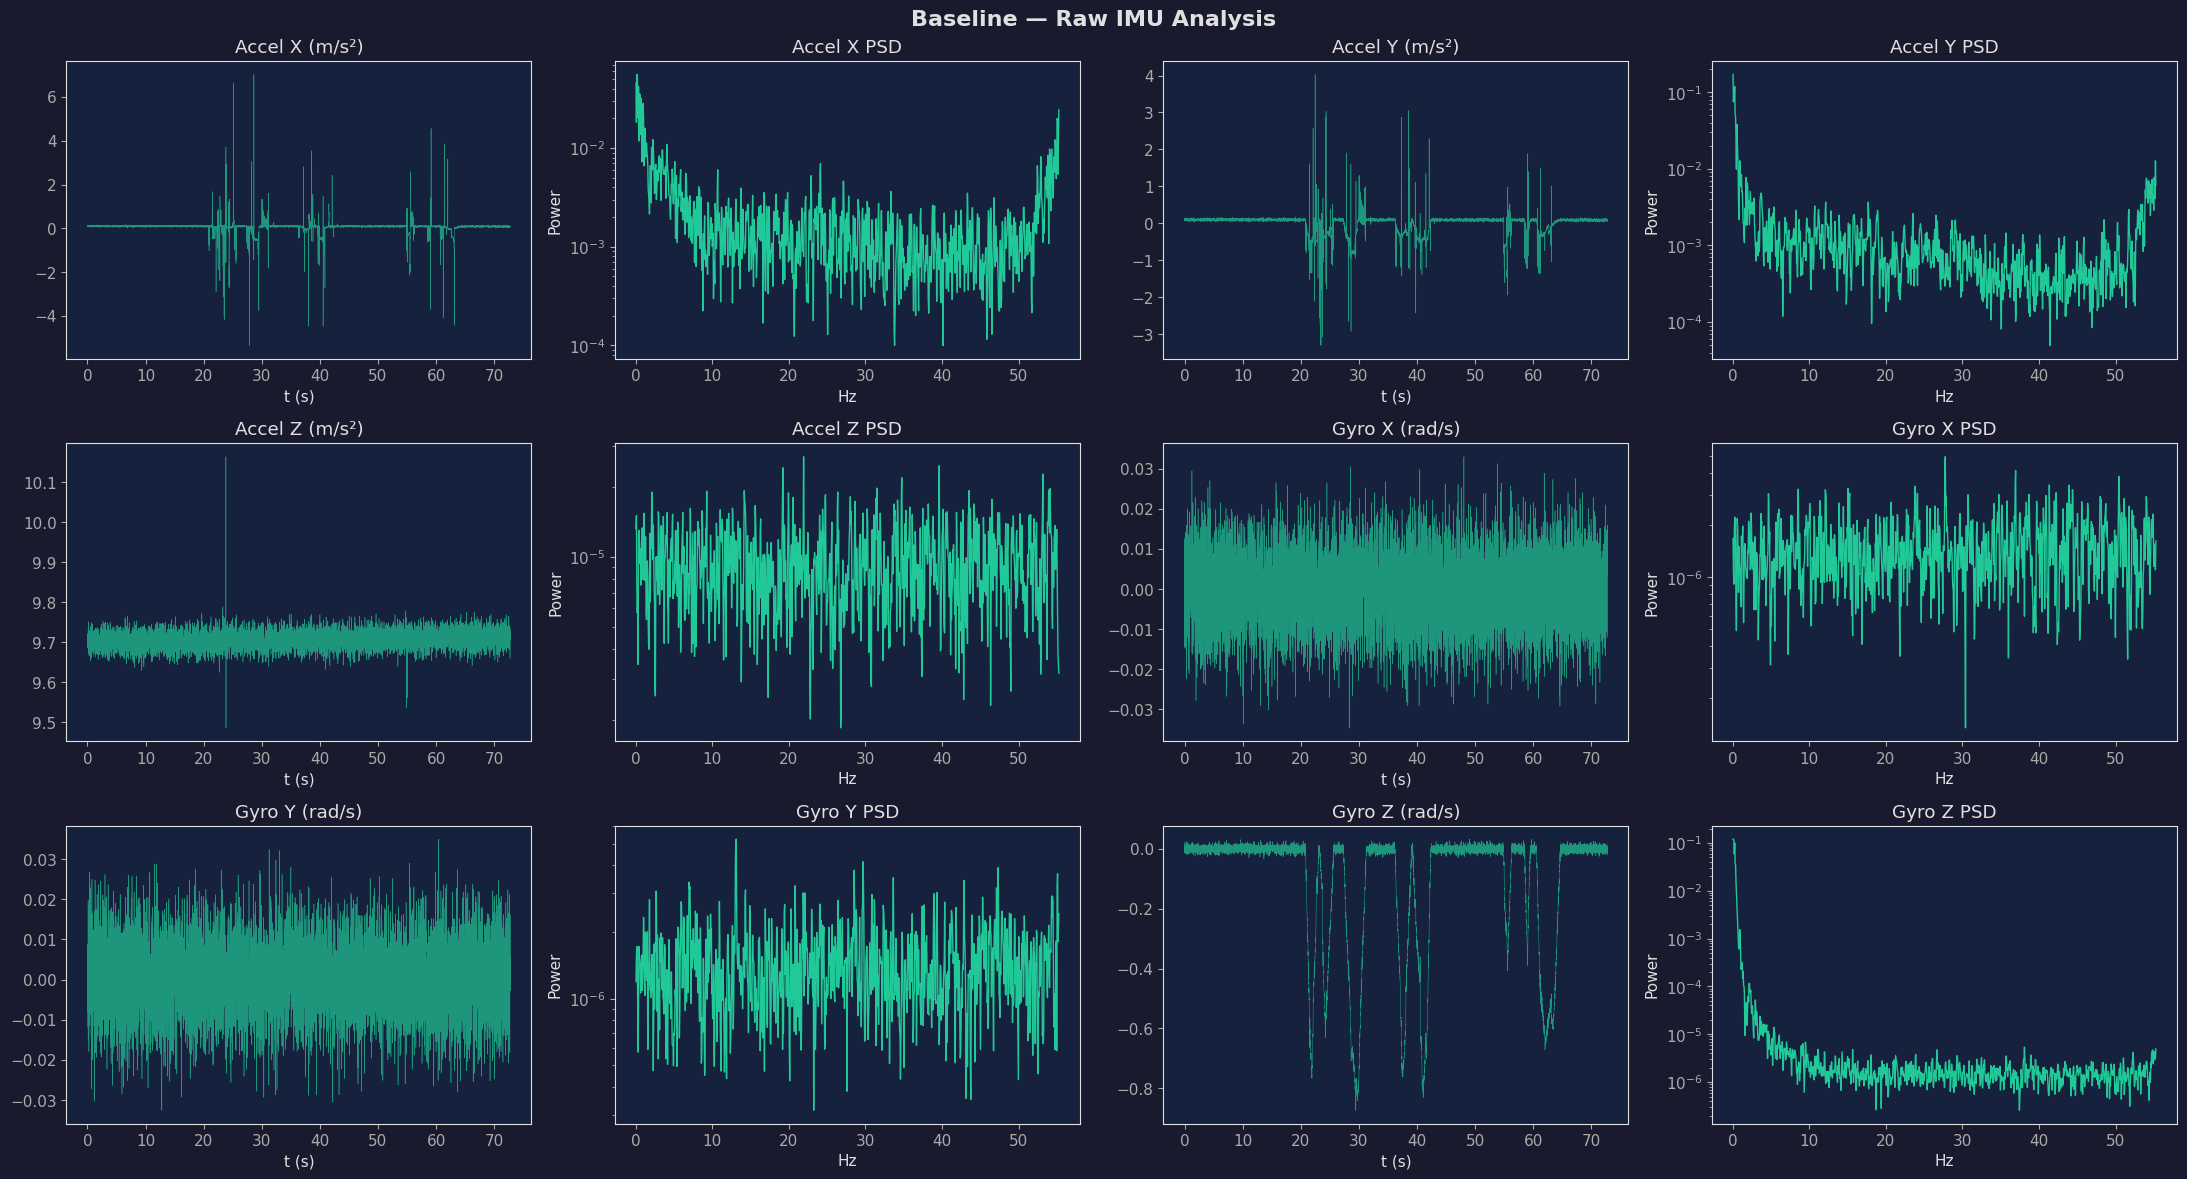


Raw IMU noise statistics:
   Channel        Mean         Std         Min         Max
────────────────────────────────────────────────────────
   Accel X     0.04484     0.35434    -5.35186     7.03057
   Accel Y    -0.01123     0.31785    -3.30608     4.03063
   Accel Z     9.70577     0.02244     9.48620    10.16369
    Gyro X    -0.00061     0.00894    -0.03466     0.03303
    Gyro Y     0.00001     0.00898    -0.03252     0.03501
    Gyro Z    -0.10840     0.21375    -0.87382     0.03312


In [6]:
if 'imu' not in dfs:
    print('No IMU data'); 
else:
    imu = dfs['imu']
    fs_imu = 1.0 / np.mean(np.diff(npc(imu, 't')))
    print(f'IMU rate: {fs_imu:.1f} Hz,  samples: {len(imu)}')

    fig, axes = plt.subplots(3, 4, figsize=(22, 12))
    fig.suptitle('Baseline — Raw IMU Analysis', fontsize=16, fontweight='bold')

    channels = [
        ('ax','Accel X','m/s²'), ('ay','Accel Y','m/s²'), ('az','Accel Z','m/s²'),
        ('gx','Gyro X','rad/s'), ('gy','Gyro Y','rad/s'), ('gz','Gyro Z','rad/s'),
    ]
    for i, (col, label, unit) in enumerate(channels):
        row, col_i = i // 2, (i % 2) * 2
        d = npc(imu, col)
        t = npc(imu, 't')
        m = mask_finite(t, d)

        # Timeseries
        axes[row, col_i].plot(t[m], d[m], color=C['imu'], lw=0.4, alpha=0.7)
        axes[row, col_i].set_title(f'{label} ({unit})')
        axes[row, col_i].set_xlabel('t (s)')

        # PSD
        d_z = d[m] - np.mean(d[m])
        nperseg = min(2048, len(d_z) // 4)
        f_psd, Pxx = welch(d_z, fs=fs_imu, nperseg=nperseg)
        axes[row, col_i+1].semilogy(f_psd[1:], Pxx[1:], color=C['imu'], lw=1)
        axes[row, col_i+1].set_title(f'{label} PSD')
        axes[row, col_i+1].set_xlabel('Hz')
        axes[row, col_i+1].set_ylabel('Power')

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/04_imu_noise.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nRaw IMU noise statistics:')
    print(f'{"Channel":>10}  {"Mean":>10}  {"Std":>10}  {"Min":>10}  {"Max":>10}')
    print('─' * 56)
    for col, label, unit in channels:
        d = npc(imu, col)
        d = d[np.isfinite(d)]
        print(f'{label:>10}  {d.mean():10.5f}  {d.std():10.5f}  {d.min():10.5f}  {d.max():10.5f}')

## 6. Visual vs LiDAR Odometry Trust Analysis
Noise level, consistency, and how much each contributes to EKF drift.

### visual vs LiDAR odometry trust analysis

before giving odometry to EKF we need to know how noisy it actually is. here we look at detrended velocity noise for visual odom and lidar odom to justify our EKF rejection thresholds and RQNN deployment decision.

**what is plotted against what:**
- left column: XY trajectory from each source (x=meters, y=meters) — geometric sense check
- middle column: histogram of detrended vx noise (x=residual m/s, y=probability density)
- right column: PSD of vx noise (x=Hz, y=power) — frequency content of noise

**detrended noise using Savitzky-Golay filter:**
$$noise_{vx} = v_x - \hat{v}_x^{SG}$$
$$\sigma_{noise} = \text{std}(noise_{vx})$$

Savitzky-Golay fit polynomial order 3 through sliding window of 51 samples. used instead of moving average because it preserve peaks and shape better (moving average would introduce phase lag in the trend estimate).

**what we can infer:**
- visual odom noise σ ≈ 0.39 m/s is very high (21× worse than wheel σ ≈ 0.018 m/s) → needs RQNN filter before EKF, or high Mahalanobis rejection threshold
- lidar odom noise σ ≈ 0.27 m/s better than visual but still significant → ICP doing internal averaging but not eliminating velocity noise
- we set `odom1_pose_rejection_threshold: 1.5` (visual) and `odom2_pose_rejection_threshold: 3.0` (lidar) in EKF config based on these noise levels
- high closure error on visual/lidar = long-run drift without loop closure correction
- this analysis directly justifies selective RQNN deployment: filter visual odom (high noise), bypass lidar (already ICP optimized)

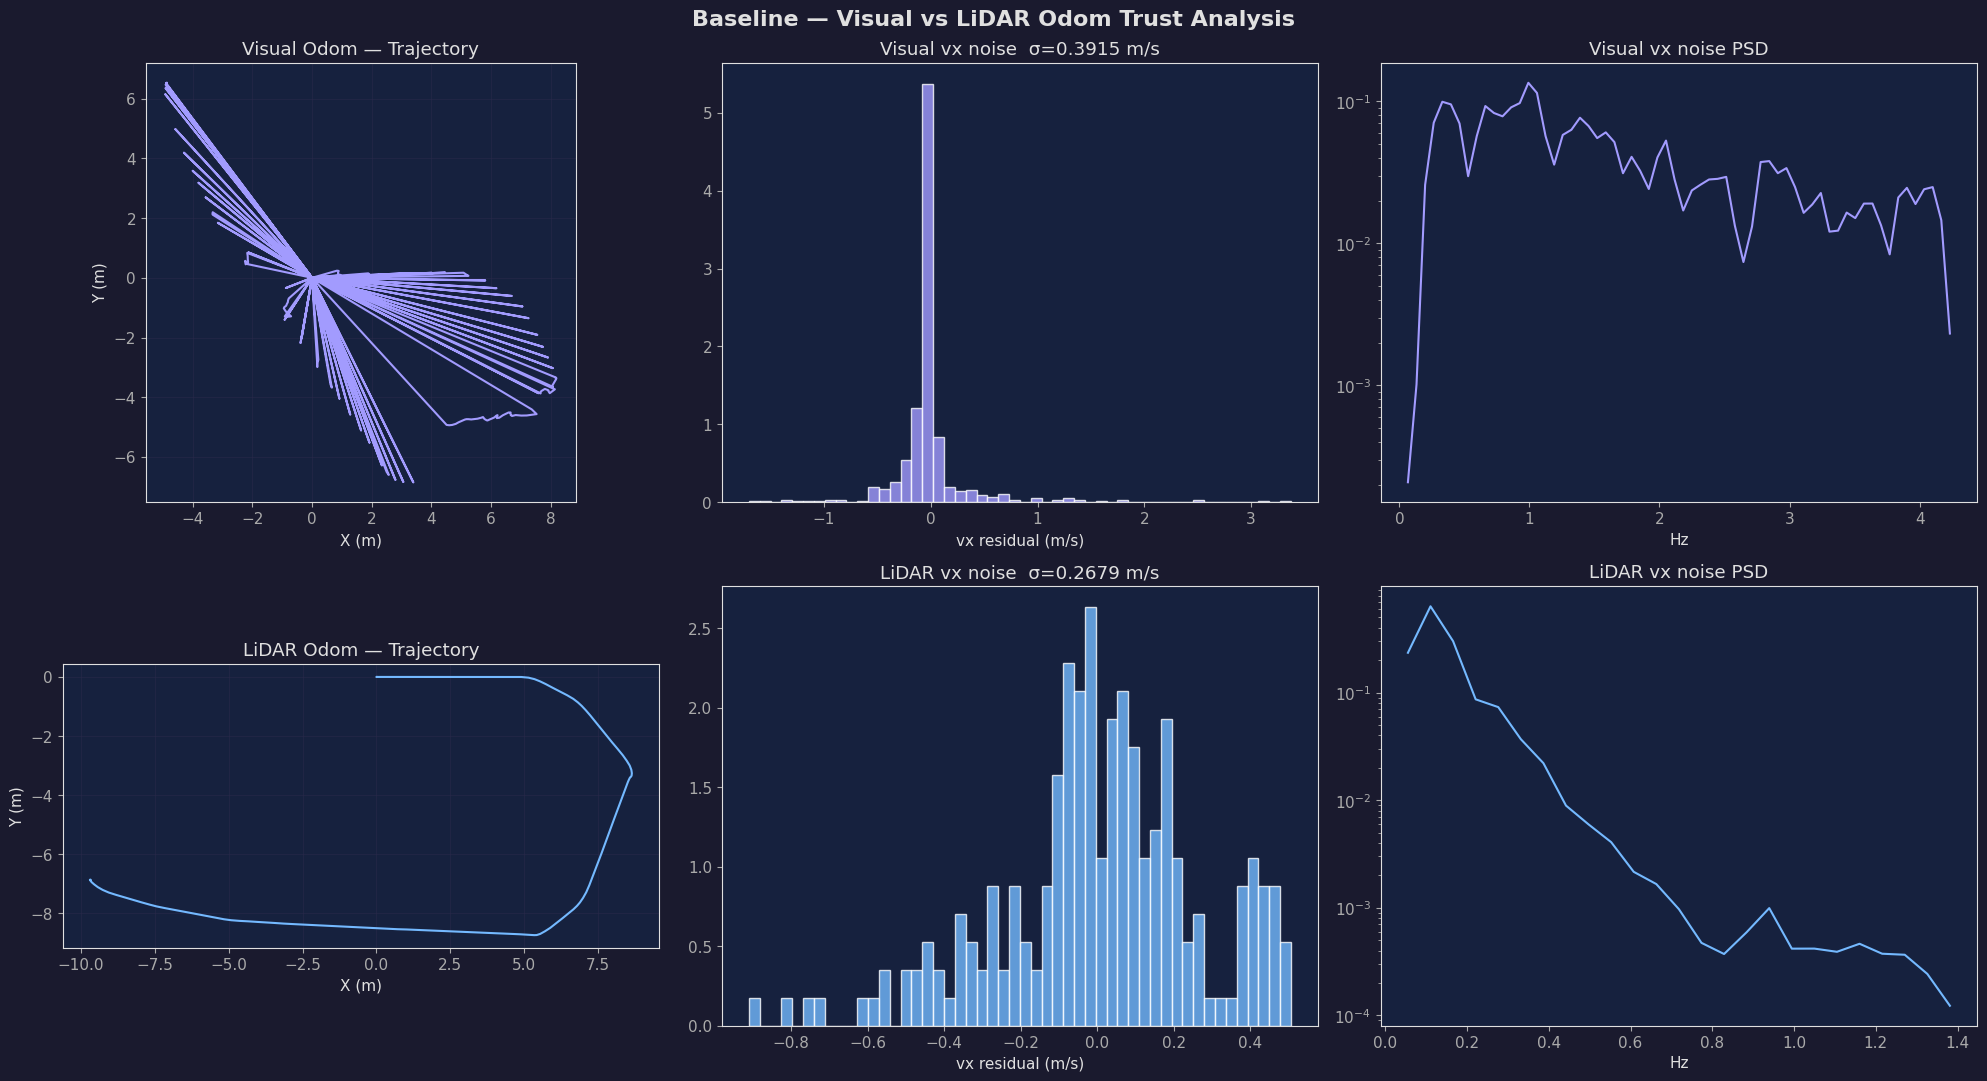


Odometry noise summary (detrended):
    Source       vx σ       wz σ     Rate    Closure
───────────────────────────────────────────────────────
     Wheel    0.01817    0.02447     27.1    10.0669 m
    Visual    0.39153    0.03875      8.5     8.1451 m
     LiDAR    0.26785    0.17696      2.8    11.8653 m


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Baseline — Visual vs LiDAR Odom Trust Analysis', fontsize=16, fontweight='bold')

for i, (k, name, color) in enumerate([('visual', 'Visual', C['visual']),
                                        ('lidar',  'LiDAR',  C['lidar'])]):
    if k not in dfs:
        continue
    df = dfs[k]
    t   = npc(df, 't')
    vx  = npc(df, 'vx')
    wz  = npc(df, 'wz')
    x   = npc(df, 'x')
    y   = npc(df, 'y')

    # Detrended vx noise
    wl = min(51, max(5, (len(df)//5)*2+1))
    if wl % 2 == 0: wl += 1
    m = mask_finite(t, vx)
    trend_vx = savgol_filter(vx[m], wl, 3)
    noise_vx = vx[m] - trend_vx

    # Trajectory
    mx = mask_finite(x, y)
    axes[i, 0].plot(x[mx], y[mx], color=color, lw=1.5)
    axes[i, 0].set_title(f'{name} Odom — Trajectory')
    axes[i, 0].set_aspect('equal'); axes[i, 0].grid(True)
    axes[i, 0].set_xlabel('X (m)'); axes[i, 0].set_ylabel('Y (m)')

    # vx noise histogram
    axes[i, 1].hist(noise_vx, bins=50, density=True, color=color, alpha=0.8, edgecolor='white')
    axes[i, 1].set_title(f'{name} vx noise  σ={noise_vx.std():.4f} m/s')
    axes[i, 1].set_xlabel('vx residual (m/s)')

    # vx PSD
    fs_k = 1.0 / np.mean(np.diff(t[m]))
    f_psd, Pxx = welch(noise_vx, fs=fs_k, nperseg=min(128, len(noise_vx)//4))
    axes[i, 2].semilogy(f_psd[1:], Pxx[1:], color=color, lw=1.5)
    axes[i, 2].set_title(f'{name} vx noise PSD')
    axes[i, 2].set_xlabel('Hz')

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/05_vo_lo_trust.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nOdometry noise summary (detrended):')
print(f'{"Source":>10}  {"vx σ":>9}  {"wz σ":>9}  {"Rate":>7}  {"Closure":>9}')
print('─' * 55)
for k, name in [('wheel','Wheel'), ('visual','Visual'), ('lidar','LiDAR')]:
    if k not in dfs: continue
    df = dfs[k]
    t  = npc(df, 't'); vx = npc(df, 'vx'); wz = npc(df, 'wz')
    x  = npc(df, 'x'); y  = npc(df, 'y')
    m  = mask_finite(t, vx)
    wl = min(51, max(5, (m.sum()//5)*2+1))
    if wl % 2 == 0: wl += 1
    std_vx = np.std(vx[m] - savgol_filter(vx[m], wl, 3))
    std_wz = np.std(wz[m] - savgol_filter(wz[m], wl, 3))
    mx = mask_finite(x, y)
    closure = np.sqrt((x[mx][-1]-x[mx][0])**2 + (y[mx][-1]-y[mx][0])**2) if mx.sum()>1 else 0
    hz = len(df) / (t[-1] - t[0]) if len(df) > 1 else 0
    print(f'{name:>10}  {std_vx:9.5f}  {std_wz:9.5f}  {hz:7.1f}  {closure:9.4f} m')

## 7. Drift Analysis — EKF Local vs Global Divergence

### drift analysis — the most important metric

drift = how far EKF output is from the true simulator position. this is ground truth comparison that actually validates our system. without this comparison we don't know if EKF is working or just doing random stuff.

**we use Gazebo /ground_truth/odom because:**
- it's exact physics engine state (zero noise)
- available only in simulation → real deployment needs different reference (e.g. RTK GPS, mocap system)

**drift computation:**
both trajectories re-centered to origin (subtract position at first shared timestamp) then euclidean distance:
$$\text{drift}(t) = \sqrt{\big(x_{ekf}(t) - x_{gt}(t)\big)^2 + \big(y_{ekf}(t) - y_{gt}(t)\big)^2}$$

**drift rate (how fast error accumulate):**
$$\text{rate} = \frac{\text{drift}(T_{end})}{T_{end} - T_{start}} \times 60 \quad [\text{m/min}]$$

**what is plotted against what:**
- left: drift in meters vs time in seconds
- right: drift rate in m/min vs time

**what we can infer:**
- EKF local drift grow without bound (expected — no GPS in odom frame, just dead-reckoning)
- EKF global drift should stay bounded because GPS provides absolute correction
- baseline final drift ≈ 0.7 m at 72.7 s = good result, within GPS noise floor (GPS σ ≈ 3 m)
- drift rate ≈ 0.577 m/min = acceptable for agricultural robot where meter-level tolerance is ok
- sudden jump in drift = GPS outlier got through or navsat datum mismatch

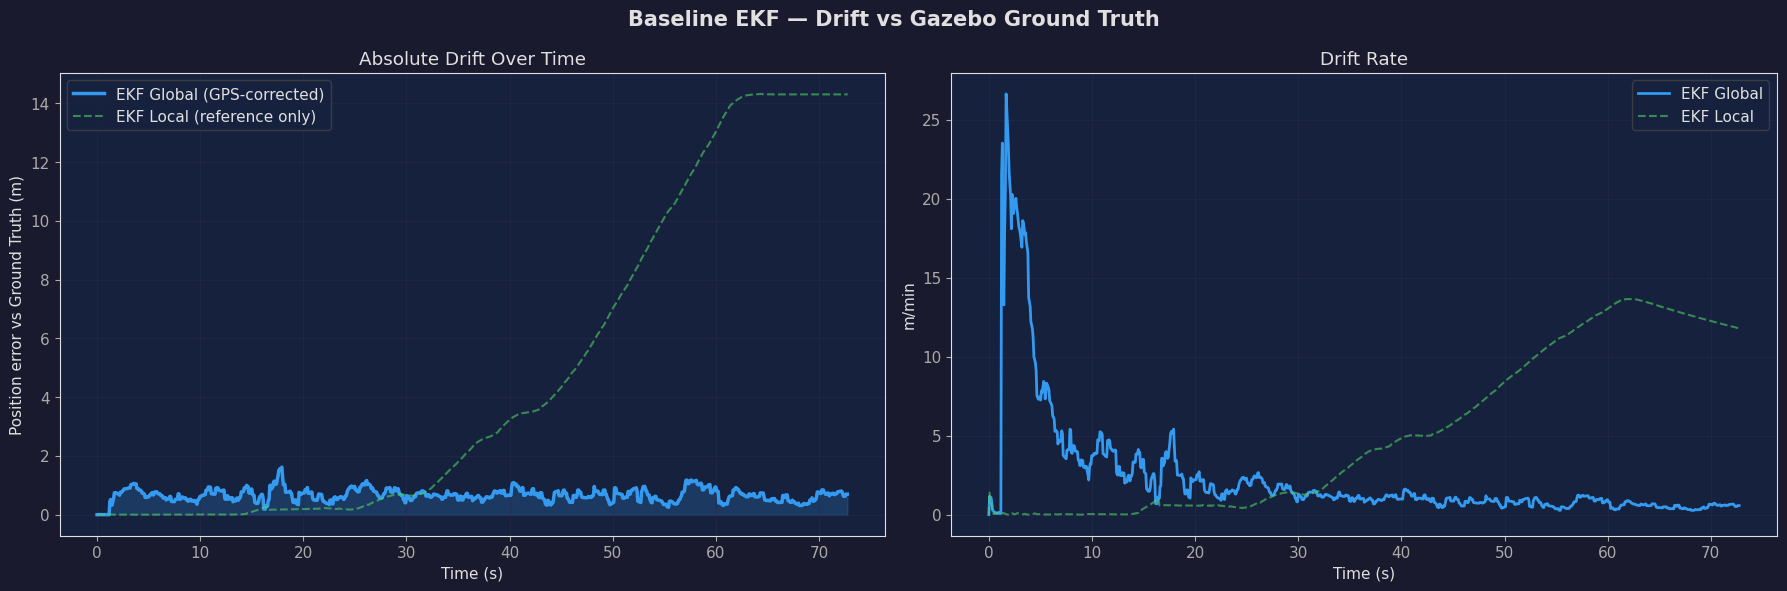

Baseline EKF — Drift Summary (vs Gazebo Ground Truth):
  EKF Global final drift : 0.6995 m
  EKF Global max drift   : 1.6183 m
  EKF Global drift rate  : 0.5770 m/min
  EKF Local  final drift : 14.3062 m  (drifts without GPS — expected)
  Target (Global)        : 5-10 m  ✓


In [8]:
# Drift metric: |ekf_global − ground_truth|
# ekf_global is the GPS-corrected final output — that's what matters for accuracy.
# ekf_local is shown for context only (always drifts — expected).

if 'ekf_global' not in dfs:
    print('No ekf_global in bag'); raise SystemExit
if 'ground_truth' not in dfs:
    print('⚠ No /ground_truth/odom — re-record bag after URDF rebuild')
    print('  Cannot compute honest drift metric without Gazebo ground truth')
    raise SystemExit

eg = dfs['ekf_global']
gt = dfs['ground_truth']

tg = npc(eg, 't'); xg = npc(eg, 'x'); yg = npc(eg, 'y')
tr = npc(gt, 't'); xr = npc(gt, 'x'); yr = npc(gt, 'y')
mg = mask_finite(tg, xg, yg); mr = mask_finite(tr, xr, yr)

t_c = np.linspace(max(tg[mg][0], tr[mr][0]), min(tg[mg][-1], tr[mr][-1]), 1000)
gx = np.interp(t_c, tg[mg], xg[mg]) - xg[mg][0]
gy = np.interp(t_c, tg[mg], yg[mg]) - yg[mg][0]
rx = np.interp(t_c, tr[mr], xr[mr]) - xr[mr][0]
ry = np.interp(t_c, tr[mr], yr[mr]) - yr[mr][0]
drift_global = np.sqrt((gx - rx)**2 + (gy - ry)**2)

# Local drift for context
el = dfs['ekf_local']
tl = npc(el,'t'); xl = npc(el,'x'); yl = npc(el,'y')
ml = mask_finite(tl, xl, yl)
t_l = np.linspace(max(tl[ml][0], tr[mr][0]), min(tl[ml][-1], tr[mr][-1]), 1000)
lx = np.interp(t_l, tl[ml], xl[ml]) - xl[ml][0]
ly = np.interp(t_l, tl[ml], yl[ml]) - yl[ml][0]
rx_l = np.interp(t_l, tr[mr], xr[mr]) - xr[mr][0]
ry_l = np.interp(t_l, tr[mr], yr[mr]) - yr[mr][0]
drift_local = np.sqrt((lx - rx_l)**2 + (ly - ry_l)**2)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Baseline EKF — Drift vs Gazebo Ground Truth', fontsize=15, fontweight='bold')

ax = axes[0]
ax.plot(t_c, drift_global, color=C['ekf_global'], lw=2.5, label='EKF Global (GPS-corrected)')
ax.fill_between(t_c, 0, drift_global, color=C['ekf_global'], alpha=0.2)
ax.plot(t_l, drift_local, color=C['ekf_local'], lw=1.5, ls='--', alpha=0.6, label='EKF Local (reference only)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Position error vs Ground Truth (m)')
ax.set_title('Absolute Drift Over Time'); ax.legend(); ax.grid(True)

ax2 = axes[1]
ax2.plot(t_c, drift_global / (t_c + 1e-6) * 60, color=C['ekf_global'], lw=2, label='EKF Global')
ax2.plot(t_l, drift_local / (t_l + 1e-6) * 60, color=C['ekf_local'], lw=1.5, ls='--', alpha=0.6, label='EKF Local')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('m/min')
ax2.set_title('Drift Rate'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/06_drift.png', dpi=150, bbox_inches='tight')
plt.show()

dur = t_c[-1] - t_c[0]
print('Baseline EKF — Drift Summary (vs Gazebo Ground Truth):')
print(f'  EKF Global final drift : {drift_global[-1]:.4f} m')
print(f'  EKF Global max drift   : {drift_global.max():.4f} m')
print(f'  EKF Global drift rate  : {drift_global[-1]/dur*60:.4f} m/min')
print(f'  EKF Local  final drift : {drift_local[-1]:.4f} m  (drifts without GPS — expected)')
print(f'  Target (Global)        : 5-10 m  {"✓" if drift_global[-1] <= 10 else "✗"}')

## 8. GPS Innovation Analysis
Innovation = GPS position − EKF global estimate. Well-tuned EKF → zero-mean Gaussian.

### GPS innovation analysis — checking if EKF is "honest"

innovation = measurement minus prediction. it tell us whether EKF is actually using GPS information correctly. well-tuned EKF should be "surprised" only by random noise, not by systematic bias.

**innovation formula:**
$$\boldsymbol{\nu} = \mathbf{z}_{GPS} - \mathbf{H}\hat{\mathbf{x}}^-$$
for GPS position measurement this simplifies to just:
$$\nu_x = x_{GPS,converted} - x_{EKF,predicted}, \quad \nu_y = y_{GPS,converted} - y_{EKF,predicted}$$
GPS converted to meters using same flat-earth formula as trajectory section

**2D RMSE of innovation:**
$$\text{RMSE}_{2D} = \sqrt{\frac{1}{N}\sum_{i}(\nu_{x,i}^2 + \nu_{y,i}^2)}$$

**Gaussian normality test:** D'Agostino K² test. p-value > 0.05 = cannot reject Gaussian assumption = EKF is consistent

**what is plotted against what:**
- left: Δx and Δy vs time (should be zero-mean, bounded, not trending upward)
- middle: histogram of innovations (should look like Gaussian bell curve if EKF tuned right)
- right: 2D scatter ΔX vs ΔY (should cluster around origin, color = time)

**what we can infer:**
- large innovation mean → GPS and EKF origin are offset (navsat datum issue), not filter problem
- wide innovation spread → GPS covariance R_gps too small (Kalman gain K too high → EKF chase GPS too aggressively)
- our GPS_VAR_HORIZONTAL = 9.0 m² was chosen to match σ ≈ 3 m scatter observed in this analysis
- non-Gaussian innovation → outliers getting through (increase Mahalanobis rejection threshold)
- scatter not symmetric around origin → possible cross-axis coupling or map rotation problem

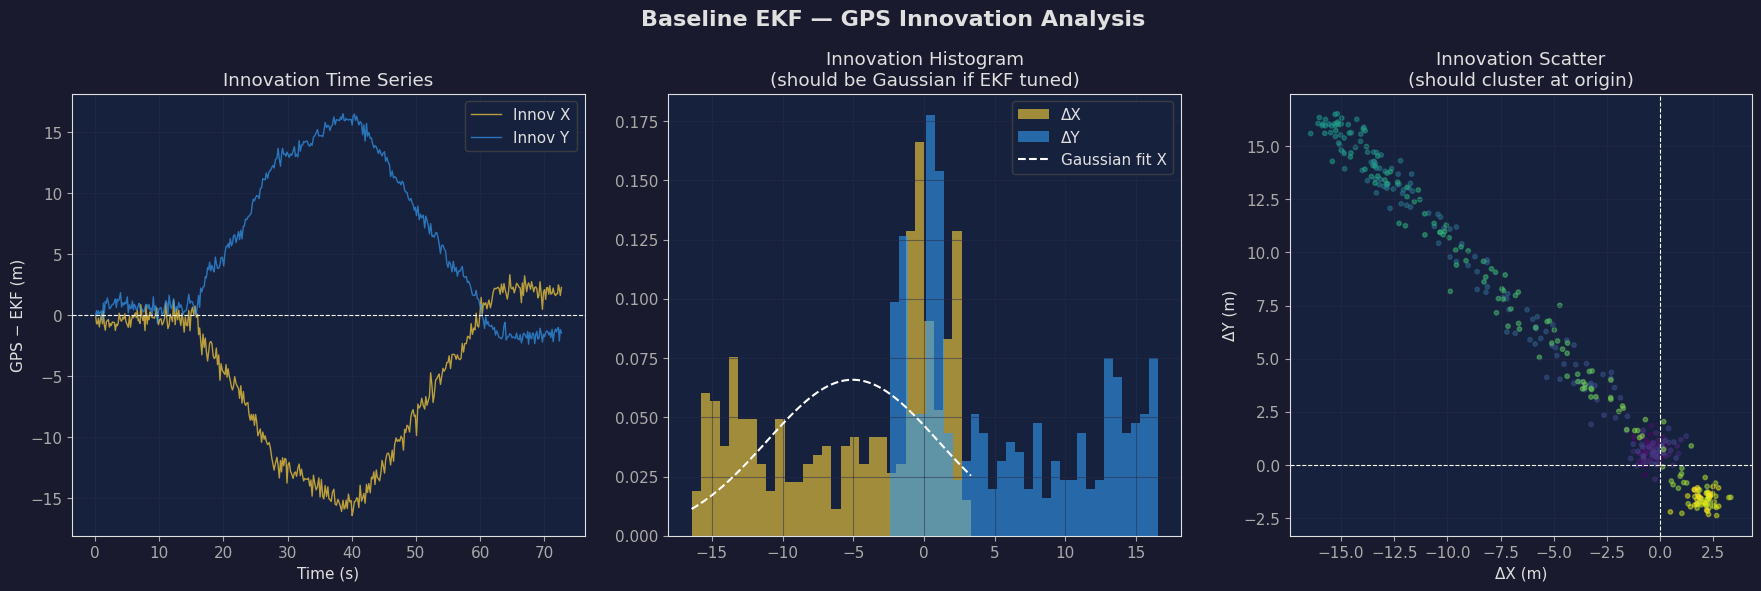


GPS Innovation Statistics (Baseline EKF):
  ΔX  mean=-5.0482 m   std=6.0592 m
  ΔY  mean=5.5843 m   std=6.1316 m
  2D RMSE = 11.4446 m
  Normality (X): p=0.0000 (>0.05 = Gaussian)
  Normality (Y): p=0.0000


In [9]:
if 'gps' not in dfs or 'ekf_global' not in dfs:
    print('Need /gps/fix and /odometry/global')
else:
    gps = dfs['gps']
    ekf = dfs['ekf_global']

    # Convert GPS lat/lon to local meters (ENU-aligned)
    lat = npc(gps, 'lat'); lon = npc(gps, 'lon')
    lat_m = (lat - lat[0]) * 111320
    lon_m = (lon - lon[0]) * 111320 * np.cos(np.radians(lat[0]))

    tg = npc(gps, 't'); te = npc(ekf, 't')
    xe = npc(ekf, 'x'); ye = npc(ekf, 'y')
    me = mask_finite(te, xe, ye)

    # Align GPS to EKF origin
    lat_m += xe[me][0] - lat_m[0]
    lon_m += ye[me][0] - lon_m[0]

    mg = mask_finite(tg, lat_m, lon_m)
    ekf_x_interp = np.interp(tg[mg], te[me], xe[me])
    ekf_y_interp = np.interp(tg[mg], te[me], ye[me])

    innov_x = lat_m[mg] - ekf_x_interp
    innov_y = lon_m[mg] - ekf_y_interp

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Baseline EKF — GPS Innovation Analysis', fontsize=16, fontweight='bold')

    axes[0].plot(tg[mg], innov_x, color=C['gps'], alpha=0.7, lw=1, label='Innov X')
    axes[0].plot(tg[mg], innov_y, color=C['ekf_global'], alpha=0.7, lw=1, label='Innov Y')
    axes[0].axhline(0, color='white', ls='--', lw=0.8)
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('GPS − EKF (m)')
    axes[0].set_title('Innovation Time Series'); axes[0].legend(); axes[0].grid(True)

    axes[1].hist(innov_x, bins=30, color=C['gps'], alpha=0.6, density=True, label='ΔX')
    axes[1].hist(innov_y, bins=30, color=C['ekf_global'], alpha=0.6, density=True, label='ΔY')
    x_range = np.linspace(innov_x.min(), innov_x.max(), 100)
    axes[1].plot(x_range, stats.norm.pdf(x_range, innov_x.mean(), innov_x.std()),
                 'w--', lw=1.5, label='Gaussian fit X')
    axes[1].set_title('Innovation Histogram\n(should be Gaussian if EKF tuned)')
    axes[1].legend(); axes[1].grid(True)

    axes[2].scatter(innov_x, innov_y, c=tg[mg], cmap='viridis', s=10, alpha=0.5)
    axes[2].axhline(0, color='white', ls='--', lw=0.8)
    axes[2].axvline(0, color='white', ls='--', lw=0.8)
    axes[2].set_xlabel('ΔX (m)'); axes[2].set_ylabel('ΔY (m)')
    axes[2].set_title('Innovation Scatter\n(should cluster at origin)')
    axes[2].set_aspect('equal'); axes[2].grid(True)

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/07_gps_innovation.png', dpi=150, bbox_inches='tight')
    plt.show()

    rmse = np.sqrt(np.mean(innov_x**2 + innov_y**2))
    print(f'\nGPS Innovation Statistics (Baseline EKF):')
    print(f'  ΔX  mean={innov_x.mean():.4f} m   std={innov_x.std():.4f} m')
    print(f'  ΔY  mean={innov_y.mean():.4f} m   std={innov_y.std():.4f} m')
    print(f'  2D RMSE = {rmse:.4f} m')
    print(f'  Normality (X): p={stats.normaltest(innov_x).pvalue:.4f} (>0.05 = Gaussian)')
    print(f'  Normality (Y): p={stats.normaltest(innov_y).pvalue:.4f}')

## 9. EKF Covariance — Uncertainty Over Time

### EKF covariance — how uncertain is the filter about its own estimate

EKF covariance matrix P diagonal give us 1-sigma uncertainty bounds on each state. useful for checking if filter is converging, diverging, or staying sensibly bounded.

**1-sigma position uncertainty:**
$$\sigma_x(t) = \sqrt{P_{xx}(t)}, \quad \sigma_y(t) = \sqrt{P_{yy}(t)}$$

**1-sigma yaw uncertainty:**
$$\sigma_\psi(t) = \sqrt{P_{\psi\psi}(t)}$$

we take absolute value before sqrt because numerical rounding can occasionally give tiny negative diagonal values (should not happen in theory but float precision sometimes do this)

**what is plotted against what:**
- x-axis = time in seconds
- y-axis = uncertainty in meters (position) or radians (yaw) as 1-sigma bounds
- EKF local (green) vs EKF global (blue) comparison

**what we can infer:**
- both start near zero because initial_estimate_covariance = 1e-9 (known spawn position)
- uncertainty grows as robot moves — process noise Q add uncertainty every prediction step
- EKF global should show periodic drops in uncertainty when GPS update arrive (measurement reduce uncertainty via Kalman gain)
- EKF local keeps growing because no absolute correction (dead-reckoning only)
- if σ_x grow very large = filter diverging, check if process noise Q is too high or sensors are being rejected constantly
- steady bounded covariance = filter working correctly, GPS corrections balanced by process noise growth

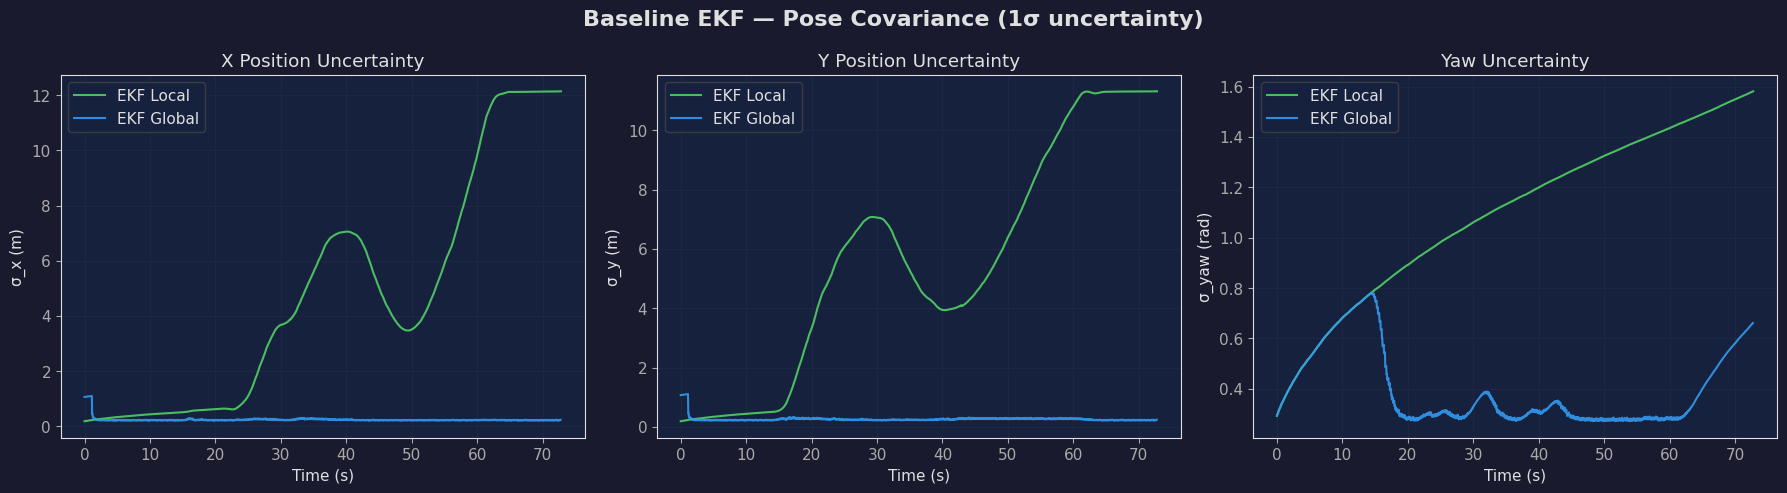

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Baseline EKF — Pose Covariance (1σ uncertainty)', fontsize=16, fontweight='bold')

for k, label, color in [('ekf_local', 'EKF Local', C['ekf_local']),
                          ('ekf_global', 'EKF Global', C['ekf_global'])]:
    if k not in dfs: continue
    df = dfs[k]
    t = npc(df, 't')
    sx = np.sqrt(np.abs(npc(df, 'cov_xx')))
    sy = np.sqrt(np.abs(npc(df, 'cov_yy')))
    syaw = np.sqrt(np.abs(npc(df, 'cov_yaw')))

    for ax, s, ylabel in zip(axes, [sx, sy, syaw],
                              ['σ_x (m)', 'σ_y (m)', 'σ_yaw (rad)']):
        m = mask_finite(t, s)
        ax.plot(t[m], s[m], color=color, lw=1.5, label=label, alpha=0.9)

for ax, ylabel, title in zip(axes,
    ['σ_x (m)', 'σ_y (m)', 'σ_yaw (rad)'],
    ['X Position Uncertainty', 'Y Position Uncertainty', 'Yaw Uncertainty']):
    ax.set_xlabel('Time (s)'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/08_covariance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary Statistics Table

In [11]:
print('=' * 70)
print('BASELINE EKF — SUMMARY')
print('Drift metric: |EKF Global − Gazebo Ground Truth|')
print('=' * 70)

if 'ekf_global' in dfs:
    d = dfs['ekf_global']
    dur = npc(d,'t')[-1] - npc(d,'t')[0]
    print(f'  Recording duration : {dur:.1f} s')

print(f'\nOdometry source noise (detrended vx std):')
for k, name in [('wheel','Wheel'), ('visual','Visual'), ('lidar','LiDAR')]:
    if k not in dfs: continue
    df = dfs[k]; vx = npc(df,'vx'); t = npc(df,'t'); m = mask_finite(t,vx)
    wl = min(51, max(5, (m.sum()//5)*2+1))
    if wl%2==0: wl+=1
    std = np.std(vx[m] - savgol_filter(vx[m], wl, 3))
    print(f'  {name:8}: vx σ = {std:.5f} m/s')

print(f'\nEKF drift vs Gazebo Ground Truth:')
if 'ekf_global' in dfs and 'ground_truth' in dfs:
    tg = npc(dfs['ekf_global'],'t');   xg = npc(dfs['ekf_global'],'x');   yg = npc(dfs['ekf_global'],'y')
    tr = npc(dfs['ground_truth'],'t'); xr = npc(dfs['ground_truth'],'x'); yr = npc(dfs['ground_truth'],'y')
    mg = mask_finite(tg,xg,yg); mr = mask_finite(tr,xr,yr)
    t_c = np.linspace(max(tg[mg][0],tr[mr][0]), min(tg[mg][-1],tr[mr][-1]), 500)
    dg = np.sqrt(
        (np.interp(t_c,tg[mg],xg[mg]-xg[mg][0]) - np.interp(t_c,tr[mr],xr[mr]-xr[mr][0]))**2 +
        (np.interp(t_c,tg[mg],yg[mg]-yg[mg][0]) - np.interp(t_c,tr[mr],yr[mr]-yr[mr][0]))**2)
    dur_c = t_c[-1] - t_c[0]
    print(f'  EKF Global final drift  : {dg[-1]:.4f} m  {"✓" if dg[-1] <= 10 else "✗"}  (target ≤ 10 m)')
    print(f'  EKF Global max drift    : {dg.max():.4f} m')
    print(f'  EKF Global drift rate   : {dg[-1]/dur_c*60:.4f} m/min')
elif 'ground_truth' not in dfs:
    print('  ⚠ No ground truth in bag — re-record to get honest metric')

print('\nIMU raw noise:')
if 'imu' in dfs:
    for col, label in [('gz','Gyro Z'),('ax','Accel X'),('ay','Accel Y')]:
        d = npc(dfs['imu'], col)
        d = d[np.isfinite(d)]
        print(f'  {label:8}: σ = {d.std():.5f}')

BASELINE EKF — SUMMARY
Drift metric: |EKF Global − Gazebo Ground Truth|
  Recording duration : 72.7 s

Odometry source noise (detrended vx std):
  Wheel   : vx σ = 0.01817 m/s
  Visual  : vx σ = 0.39153 m/s
  LiDAR   : vx σ = 0.26785 m/s

EKF drift vs Gazebo Ground Truth:
  EKF Global final drift  : 0.6995 m  ✓  (target ≤ 10 m)
  EKF Global max drift    : 1.6269 m
  EKF Global drift rate   : 0.5770 m/min

IMU raw noise:
  Gyro Z  : σ = 0.21375
  Accel X : σ = 0.35434
  Accel Y : σ = 0.31785
